<a href="https://colab.research.google.com/github/Krishs15/DeepLearning_2025-2026/blob/main/DL_LAB05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 29.7M/29.7M [00:02<00:00, 12.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/versions/1
['cropped_lisa_1']
['val_1', 'train_1']
['warning', 'go', 'stopLeft', 'stop', 'goForward', 'warningLeft', 'goLeft']


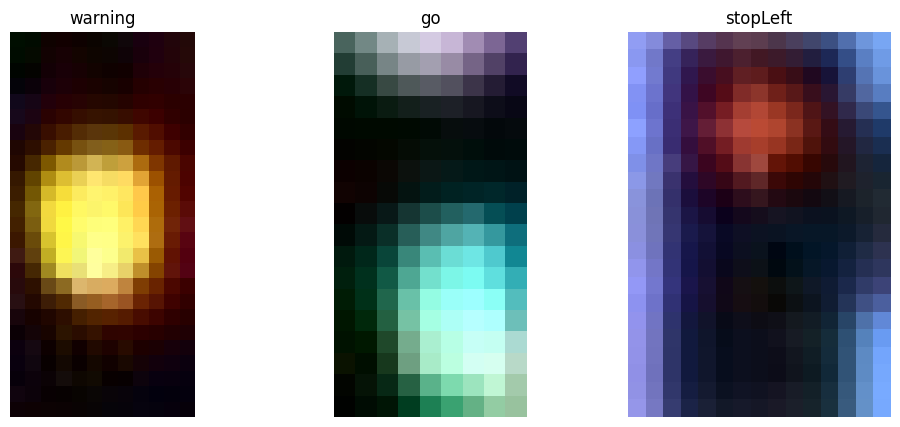

Found 28690 images belonging to 3 classes.
Found 3257 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,539 (6.20 MB)

 Trainable params: 1,625,539 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 181s 199ms/step - accuracy: 0.9898 - loss: 0.0347 - val_accuracy: 1.0000 - val_loss: 9.1581e-04
Epoch 2/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 175s 195ms/step - accuracy: 0.9972 - loss: 0.0106 - val_accuracy: 0.9972 - val_loss: 0.0064
Epoch 3/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 172s 192ms/step - accuracy: 0.9978 - loss: 0.0083 - val_accuracy: 0.9991 - val_loss: 0.0041
Epoch 4/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 178s 199ms/step - accuracy: 0.9982 - loss: 0.0101 - val_accuracy: 0.9991 - val_loss: 0.0025
Epoch 5/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 197s 193ms/step - accuracy: 0.9988 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 7.3434e-05
Epoch 6/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 173s 193ms/step - accuracy: 0.9980 - loss: 0.0085 - val_accuracy: 0.9985 - val_loss: 0.0039
Epoch 7/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 176s 197ms/step - accuracy: 0.9986 - loss: 0.0068 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 8/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 173s 192ms/step - accuracy: 

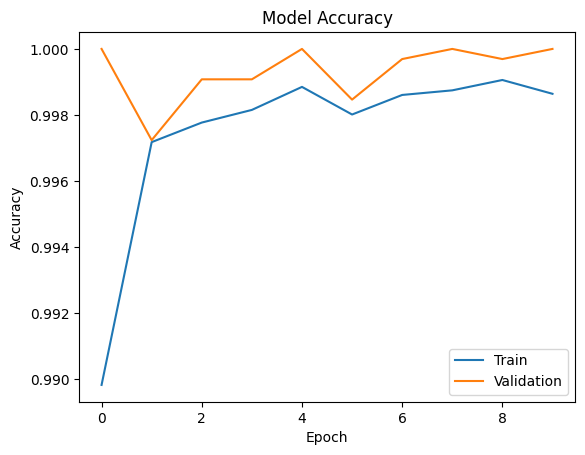

['.config', 'model.pkl', 'sample_data']


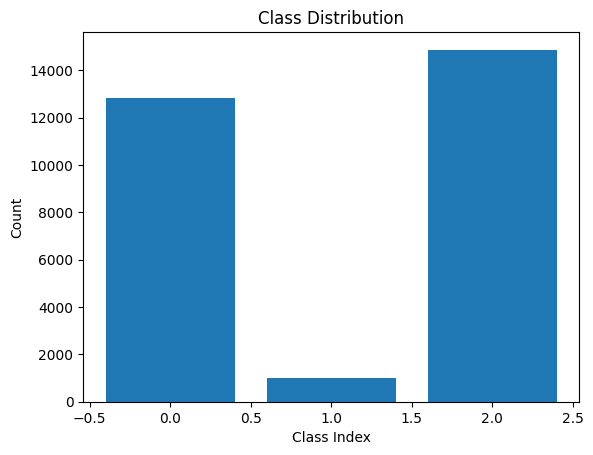

102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step


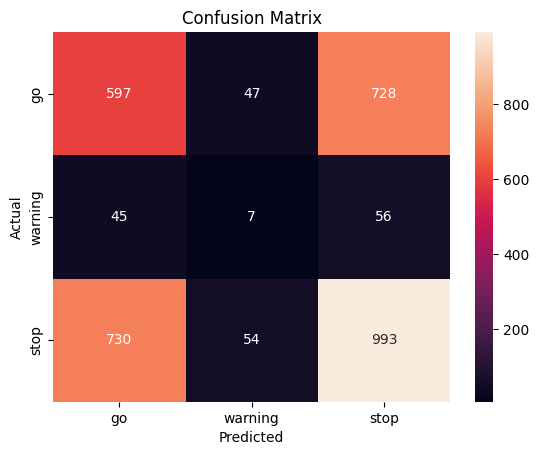

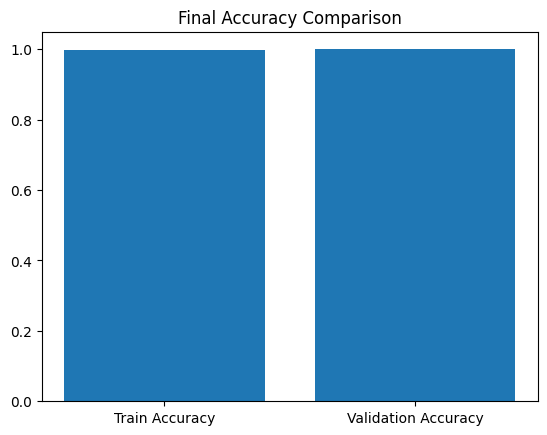

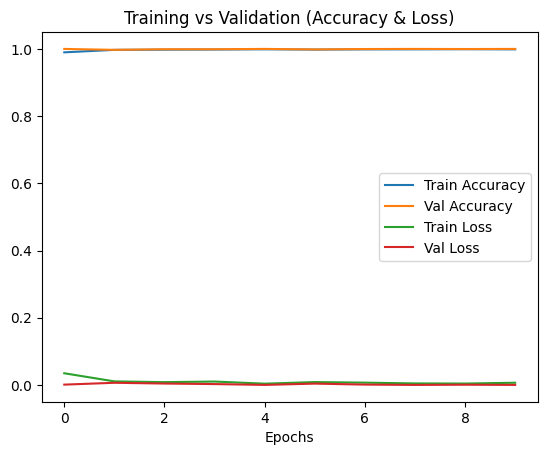

In [3]:
import numpy as np
import pandas as pd
import os
import random
import pickle
import collections
import matplotlib.pyplot as plt
import kagglehub

from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# ─── STEP 1: DOWNLOAD DATASET ─────────────────────────────
path = kagglehub.dataset_download("chandanakuntala/cropped-lisa-traffic-light-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

# ─── STEP 2: SET TRAIN AND VALIDATION PATHS ────────────────────────────────────
dataset_path = os.path.join(path, "cropped_lisa_1")
train_dir = os.path.join(dataset_path, "train_1")
val_dir   = os.path.join(dataset_path, "val_1")

print(os.listdir(dataset_path))

# ─── STEP 3: LIST AVAILABLE CLASSES ────────────────────────────────────────────
classes = os.listdir(train_dir)
print(classes)

# ─── STEP 4: VISUALIZE SAMPLE IMAGES ───────────────────────────────────────────
plt.figure(figsize=(12, 5))
for i, cls in enumerate(classes[:3]):
    folder   = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

# ─── STEP 5: DATA AUGMENTATION & LOADING ───────────────────────────────────────
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    classes=['go', 'warning', 'stop']   # IMPORTANT
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    classes=['go', 'warning', 'stop']
)

# ─── STEP 6: BUILD THE CNN MODEL ───────────────────────────────────────────────
model = Sequential([
    # 1st Conv Block
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),
    # 2nd Conv Block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    # Output Layer (3 classes: go, warning, stop)
    Dense(3, activation='softmax')
])

# ─── STEP 7: COMPILE MODEL ─────────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ─── STEP 8: TRAIN THE MODEL ───────────────────────────────────────────────────
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ─── STEP 9: PLOT MODEL ACCURACY ───────────────────────────────────────────────
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# ─── STEP 10: SAVE MODEL ───────────────────────────────────────────────────────
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print(os.listdir("."))

# ─── STEP 11: CLASS DISTRIBUTION ───────────────────────────────────────────────
counter = collections.Counter(train_data.classes)
plt.figure()
plt.bar(counter.keys(), counter.values())
plt.title("Class Distribution")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

# ─── STEP 12: CONFUSION MATRIX ─────────────────────────────────────────────────
y_pred = model.predict(val_data)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ─── STEP 13: FINAL ACCURACY COMPARISON BAR ────────────────────────────────────
train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]

plt.figure()
plt.bar(['Train Accuracy', 'Validation Accuracy'], [train_acc, val_acc])
plt.title("Final Accuracy Comparison")
plt.show()

# ─── STEP 14: TRAINING VS VALIDATION (ACCURACY & LOSS) ─────────────────────────
plt.figure()
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['loss'],         label='Train Loss')
plt.plot(history.history['val_loss'],     label='Val Loss')

plt.legend()
plt.title('Training vs Validation (Accuracy & Loss)')
plt.xlabel('Epochs')
plt.show()